# Resolviendo XOR — De compuertas anidadas al MLP
### Módulo 3 — Aprendizaje Automático

**El problema:** XOR no es linealmente separable, por lo que un perceptrón de una sola capa **nunca** puede resolverlo.  
**Las soluciones que veremos:**

| Parte | Enfoque | ¿Aprende solo? |
|-------|---------|----------------|
| 1 | Compuertas anidadas (OR + NAND + AND) | ❌ Pesos a mano |
| 2 | Perceptrón simple con sklearn | ❌ No converge |
| 3 | MLPClassifier de sklearn | ✅ Lo aprende solo |

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports
# ═══════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier   # ← el protagonista de la Parte 3

# Dataset XOR — las 4 combinaciones posibles de 2 bits
# Es el mismo que usamos en todas las compuertas
inputs = np.array([[0,0], [0,1], [1,0], [1,1]])
targets_xor = np.array([0, 1, 1, 0])              # tabla de verdad del XOR

print("Inputs:")
print(inputs)
print("\nTargets XOR:", targets_xor)

Inputs:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Targets XOR: [0 1 1 0]


---
## Parte 1 — XOR a mano: compuertas anidadas

La idea clásica: XOR se puede construir combinando tres compuertas que SÍ son linealmente separables.

```
              ┌─────┐
  x1, x2 ──► │ OR  │ ──► salida_or  ──► ┌─────┐
              └─────┘                    │ AND │ ──► XOR
  x1, x2 ──► ┌──────┐ ──► salida_nand ► └─────┘
              │ NAND │
              └──────┘
```

**Importante:** aquí los pesos están definidos a mano. El perceptrón no aprendió nada,  
nosotros le dijimos exactamente qué valores usar.

In [2]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — XOR manual con pesos a mano
# ═══════════════════════════════════════════════════════════════

def escalon(x):
    """Función de activación escalón: 1 si x>=0, sino 0."""
    return 1 if x >= 0 else 0

# Perceptrón OR: activa si al menos una entrada es 1
# w=[1,1], b=-0.5 → umbral a la mitad → 0+0=-0.5 (falla), 0+1=0.5 (pasa)
def OR(x):
    w = np.array([1, 1])
    b = -0.5
    return escalon(np.dot(x, w) + b)

# Perceptrón NAND: activa en todo MENOS cuando ambas entradas son 1
# w=[-1,-1], b=1.5 → -1-1+1.5=-0.5 (falla), -1+1.5=0.5 (pasa)
def NAND(x):
    w = np.array([-1, -1])
    b = 1.5
    return escalon(np.dot(x, w) + b)

# Perceptrón AND: activa solo cuando las DOS entradas son 1
# w=[1,1], b=-1.5 → 1+1-1.5=0.5 (pasa), 1+0-1.5=-0.5 (falla)
def AND(x):
    w = np.array([1, 1])
    b = -1.5
    return escalon(np.dot(x, w) + b)

# XOR: combina OR y NAND como capa oculta, luego AND como salida
# Esto es básicamente un MLP manual de 2 capas
def XOR(x):
    salida_or   = OR(x)    # capa oculta, neurona 1
    salida_nand = NAND(x)  # capa oculta, neurona 2
    # la capa de salida recibe los resultados de la capa oculta
    return AND(np.array([salida_or, salida_nand]))

# ── Prueba con todos los casos ──────────────────────────────────
print("═" * 40)
print("  PARTE 1 — XOR a mano")
print("═" * 40)
print(f"{'x1':>4} {'x2':>4} {'OR':>5} {'NAND':>6} {'XOR':>5} {'OK':>4}")
print("─" * 40)

correctos = 0
for x, t in zip(inputs, targets_xor):
    pred = XOR(x)
    ok = '✅' if pred == t else '❌'
    if pred == t:
        correctos += 1
    print(f"{x[0]:>4} {x[1]:>4} {OR(x):>5} {NAND(x):>6} {pred:>5} {ok:>4}")

print("─" * 40)
print(f"  Resultado: {correctos}/{len(inputs)} correctos ✅")

════════════════════════════════════════
  PARTE 1 — XOR a mano
════════════════════════════════════════
  x1   x2    OR   NAND   XOR   OK
────────────────────────────────────────
   0    0     0      1     0    ✅
   0    1     1      1     1    ✅
   1    0     1      1     1    ✅
   1    1     1      0     0    ✅
────────────────────────────────────────
  Resultado: 4/4 correctos ✅


---
## Parte 2 — ¿Por qué un perceptrón simple NO puede resolver XOR?

Un perceptrón de una capa traza **una sola línea recta** para separar las clases.  
XOR tiene sus 1s en esquinas diagonales opuestas → **ninguna línea los puede separar**.

Veamos que sklearn tampoco puede, aunque entrene muchas épocas.

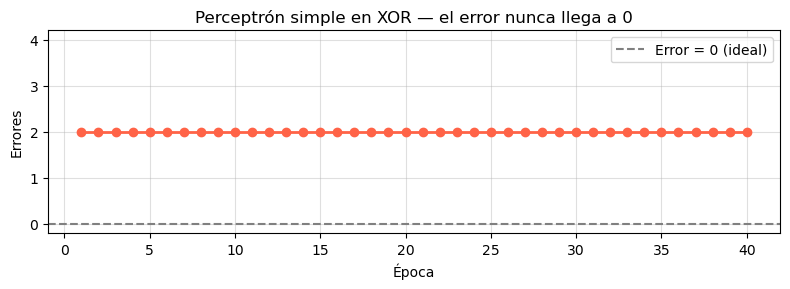

Predicciones finales: [0 0 0 0]
Targets reales:       [0 1 1 0]

→ El perceptrón oscila sin converger.
→ XOR NO es linealmente separable: necesitamos una capa oculta.


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3 — Perceptrón simple de sklearn en XOR (spoiler: falla)
# ═══════════════════════════════════════════════════════════════

# Igual que en SKlearnDiplo.ipynb pero ahora con XOR
# eta0 = tasa de aprendizaje, max_iter con warm_start para ver épocas
perceptron = Perceptron(eta0=0.1, max_iter=1, warm_start=True)

epochs = 40
errores = []

# Entrenamiento inicial para inicializar el modelo
perceptron.partial_fit(inputs, targets_xor, classes=np.array([0, 1]))

# Entrenamos época por época para registrar el error en cada una
for epoch in range(epochs):
    perceptron.partial_fit(inputs, targets_xor)
    preds = perceptron.predict(inputs)
    error = np.sum(preds != targets_xor)  # cuántas predicciones son incorrectas
    errores.append(error)

# Gráfica de error por época
plt.figure(figsize=(8, 3))
plt.plot(range(1, epochs+1), errores, marker='o', color='tomato', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', label='Error = 0 (ideal)')
plt.xlabel("Época")
plt.ylabel("Errores")
plt.title("Perceptrón simple en XOR — el error nunca llega a 0")
plt.ylim(-0.2, 4.2)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Predicciones finales: {perceptron.predict(inputs)}")
print(f"Targets reales:       {targets_xor}")
print(f"\n→ El perceptrón oscila sin converger.")
print(f"→ XOR NO es linealmente separable: necesitamos una capa oculta.")

---
## Parte 3 — XOR con MLPClassifier (sklearn)

El **Perceptrón Multicapa** (MLP) agrega una o más **capas ocultas** entre la entrada y la salida.  
Cada capa oculta puede aprender representaciones intermedias del problema.

Para XOR con 2 entradas, basta con **1 capa oculta de 2 neuronas**:

```
Entrada (2)  →  Capa oculta (2 neuronas)  →  Salida (1)

 x1 ──┐
       ├──► neurona_oculta_1 ──┐
 x2 ──┤                        ├──► neurona_salida ──► XOR
       └──► neurona_oculta_2 ──┘
```

La clave: ahora se usa **retropropagación** + **descenso por gradiente** para ajustar  
los pesos de TODAS las capas a la vez. El modelo aprende solo.

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — MLPClassifier resuelve XOR
# ═══════════════════════════════════════════════════════════════

# MLPClassifier — Perceptrón Multicapa de sklearn
# Parámetros clave:
#   hidden_layer_sizes=(2,) → 1 capa oculta con 2 neuronas
#                             Si fuera (4, 3) sería 2 capas: 4 y 3 neuronas
#   activation='logistic'   → función sigmoide en cada neurona
#                             Otras opciones: 'relu', 'tanh'
#   solver='sgd'            → gradiente descendente estocástico
#                             Igual que en el perceptrón, pero ahora propaga
#                             el error hacia atrás (backpropagation)
#   learning_rate_init=0.1  → tasa de aprendizaje inicial
#   max_iter=1000           → máximo de iteraciones completas del dataset
#   random_state=42         → semilla para reproducibilidad

mlp = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation='logistic',
    solver='sgd',
    learning_rate_init=0.1,
    max_iter=100_000,
    random_state=42
)

# fit() = entrenar: el MLP ajusta sus pesos automáticamente
# A diferencia de la Parte 1, aquí NO definimos ningún peso a mano
mlp.fit(inputs, targets_xor)

# Predicciones sobre los mismos datos de entrenamiento
predicciones = mlp.predict(inputs)

# ── Tabla de resultados ─────────────────────────────────────────
print("═" * 40)
print("  PARTE 3 — XOR con MLPClassifier")
print("═" * 40)
print(f"{'x1':>4} {'x2':>4} {'pred':>6} {'real':>6} {'OK':>4}")
print("─" * 40)

correctos = 0
for x, pred, real in zip(inputs, predicciones, targets_xor):
    ok = '✅' if pred == real else '❌'
    if pred == real:
        correctos += 1
    print(f"{x[0]:>4} {x[1]:>4} {pred:>6} {real:>6} {ok:>4}")

print("─" * 40)
print(f"  Resultado: {correctos}/{len(inputs)} correctos")
print()

# ── Información del modelo entrenado ────────────────────────────
# loss_curve_ registra el error (pérdida) por iteración durante el entrenamiento
print(f"Iteraciones usadas: {mlp.n_iter_}")
print(f"Loss final:         {mlp.loss_:.6f}")
print()

# Los pesos aprendidos por el MLP
# coefs_[0] → pesos de entrada → capa oculta  (shape: 2 entradas × 2 neuronas)
# coefs_[1] → pesos de capa oculta → salida   (shape: 2 neuronas × 1 salida)
print("Pesos aprendidos — capa oculta:")
print(mlp.coefs_[0])
print("Pesos aprendidos — capa salida:")
print(mlp.coefs_[1])

════════════════════════════════════════
  PARTE 3 — XOR con MLPClassifier
════════════════════════════════════════
  x1   x2   pred   real   OK
────────────────────────────────────────
   0    0      0      0    ✅
   0    1      0      1    ❌
   1    0      1      1    ✅
   1    1      0      0    ✅
────────────────────────────────────────
  Resultado: 3/4 correctos

Iteraciones usadas: 20
Loss final:         0.694030

Pesos aprendidos — capa oculta:
[[-0.12883721  0.61766775]
 [ 0.32799073  0.13107203]]
Pesos aprendidos — capa salida:
[[-0.76356561]
 [ 0.52016443]]


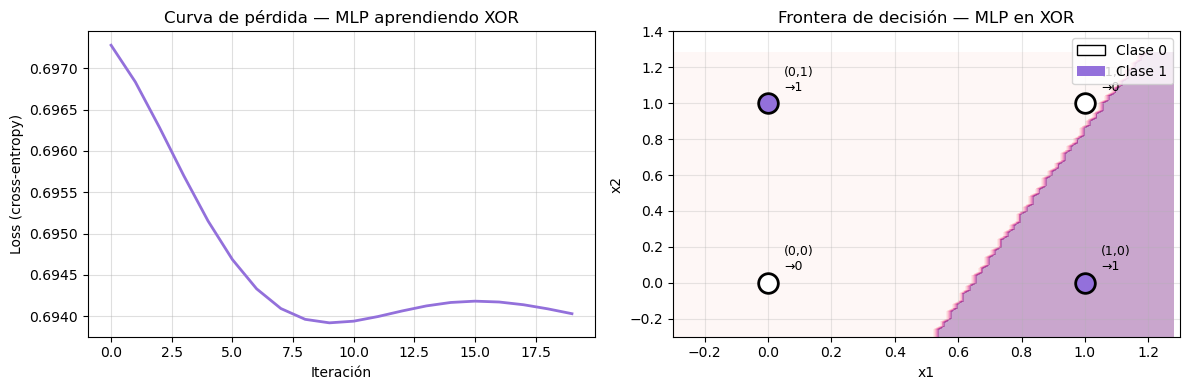

→ La frontera NO es una línea recta.
→ El MLP aprendió una frontera CURVA que sí puede separar el XOR.


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — Curva de pérdida + frontera de decisión
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Gráfica 1: curva de pérdida ─────────────────────────────────
# loss_curve_ muestra cómo fue bajando el error durante el entrenamiento
# Queremos ver que el error sí converge (a diferencia del perceptrón simple)
axes[0].plot(mlp.loss_curve_, color='mediumpurple', linewidth=2)
axes[0].set_title('Curva de pérdida — MLP aprendiendo XOR')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Loss (cross-entropy)')
axes[0].grid(True, alpha=0.4)

# ── Gráfica 2: frontera de decisión ────────────────────────────
# Creamos una malla densa de puntos para ver qué predice el MLP en cada zona
# Esto nos permite visualizar la frontera (no lineal) que aprendió
h = 0.02  # resolución de la malla
xx, yy = np.meshgrid(
    np.arange(-0.3, 1.3, h),
    np.arange(-0.3, 1.3, h)
)

# Predecimos para cada punto de la malla
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Coloreamos las regiones según la predicción
axes[1].contourf(xx, yy, Z, alpha=0.35, cmap='RdPu')

# Graficamos los 4 puntos del XOR
# Separamos por clase: 0 = círculo vacío, 1 = círculo lleno
colores = ['white' if t == 0 else 'mediumpurple' for t in targets_xor]
for i, (x, t) in enumerate(zip(inputs, targets_xor)):
    axes[1].scatter(*x, c=colores[i], s=200,
                    edgecolors='black', linewidths=2, zorder=5)
    axes[1].annotate(f"({x[0]},{x[1]})\n→{t}",
                     xy=x, xytext=(x[0]+0.05, x[1]+0.07),
                     fontsize=9)

axes[1].set_title('Frontera de decisión — MLP en XOR')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].set_xlim(-0.3, 1.3)
axes[1].set_ylim(-0.3, 1.4)
axes[1].grid(True, alpha=0.3)

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor='white', edgecolor='black', label='Clase 0'),
    Patch(facecolor='mediumpurple', label='Clase 1')
]
axes[1].legend(handles=leyenda, loc='upper right')

plt.tight_layout()
plt.show()

print("→ La frontera NO es una línea recta.")
print("→ El MLP aprendió una frontera CURVA que sí puede separar el XOR.")

---
## Resumen

| | Parte 1 (manual) | Parte 2 (perceptrón) | Parte 3 (MLP) |
|---|---|---|---|
| ¿Resuelve XOR? | ✅ | ❌ | ✅ |
| ¿Aprende solo? | ❌ | ❌ | ✅ |
| ¿Cómo? | Pesos a mano | Regla Rosenblatt | Backpropagation |
| Capa oculta | Sí (OR+NAND) | No | Sí (aprendida) |
| Frontera | Quebrada (lógica) | Lineal (falla) | Curva (aprendida) |

**Conclusión:** XOR fue el problema que demostró históricamente que los perceptrones de  
una capa tienen límites fundamentales, y motivó el desarrollo del MLP con retropropagación.

> *La capa oculta es lo que le da poder al MLP: cada neurona oculta aprende una  
> representación diferente de los datos, y juntas pueden separar clases que ninguna  
> línea recta podría separar.*